# UR5: the complete URDF2DT workflow

This worked example uses the bundled serial UR5 fixture and **Standard DH**, with metres and radians throughout. Run every cell in order with **Restart Kernel and Run All**. The scripted walkthrough performs an actual compensated frame edit; an optional live editor follows it.

From the repository terminal, install and launch using the same interpreter:
```powershell
.\.venv\Scripts\python.exe -m pip install -e ".[ui]"
.\.venv\Scripts\python.exe -m jupyterlab examples/ur5_full_pipeline.ipynb
```
Select a kernel using the project virtual environment. The 3-D illustration needs a working local VTK/OpenGL renderer. Outputs go to a new directory on each run, so previous sessions are preserved. Tolerances are provisional pending advisor/reference reconciliation; sampled FK is not a proof over continuous joint space.

## 1. Imports and configuration
Load the project configuration and record the interpreter used by this kernel.

In [1]:
from pathlib import Path
from dataclasses import asdict
from tempfile import mkdtemp
from html import escape
import json
import sys
from IPython.display import display, Markdown, HTML, Image
from urdf2dt.config import load_config
from urdf2dt.parser.urdf_input import URDFInput
from urdf2dt.parser.urdf_validator import validate_urdf
from urdf2dt.parser.urdf_parser import SerialURDFParser
from urdf2dt.dh.dh_solver import StandardDHSolver
from urdf2dt.pipeline import generate_automatic_model
from urdf2dt.dh.editor_session import EditorSession
from urdf2dt.dh.recompute import FrameEdit, recompute_model
from urdf2dt.dh.classification import classify_dh_model, get_editable_params
from urdf2dt.dh.global_validation import validate_global_fk
from urdf2dt.dh.types import FrameState
from urdf2dt.visualization.scene import StaticScene
from urdf2dt.export.persistence import save_session, load_session

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / 'robots/ur5/ur5_serial.urdf').is_file()
             and (p / 'pyproject.toml').is_file()), None)
if ROOT is None:
    raise RuntimeError('Start Jupyter from the URDF2DT repository or its examples folder.')
config = load_config()
print('Python:', sys.executable)
print(json.dumps(config.snapshot(), indent=2))

Python: C:\Users\abdel\OneDrive\Desktop\URDF2DT\outputs\tmp\stage21-venv\Scripts\python.exe
{
  "geometry": {
    "parallel_threshold": 1e-05,
    "intersection_threshold": 1e-06,
    "common_normal_threshold": 1e-06
  },
  "validation": {
    "position_tolerance_m": 0.0001,
    "orientation_tolerance_rad": 0.0001,
    "samples": 50,
    "random_seed": 42
  },
  "ui": {
    "live_preview": true
  },
  "logging": {
    "level": "INFO"
  },
  "reference_status": "provisional",
  "reference_note": "Plan section 10; advisor/report reconciliation pending."
}


## 2. Select the URDF
This example selects a bundled serial chain. A whole branching robot must first have a root-to-leaf chain selected in the desktop application.

In [2]:
source_path = ROOT / 'robots/ur5/ur5_serial.urdf'
source = URDFInput.from_path(source_path)
print('Source:', source.name)
print('SHA-256:', source.sha256)
output_parent = ROOT / 'outputs' / 'notebooks'
output_parent.mkdir(parents=True, exist_ok=True)
output_dir = Path(mkdtemp(prefix='ur5_worked_', dir=output_parent))
print('This run:', output_dir)

Source: ur5_serial.urdf
SHA-256: 2dc91dafb13f23beadb867f81880db1de4baa963973e768521ab7abbc5314882
This run: C:\Users\abdel\OneDrive\Desktop\URDF2DT\outputs\tmp\stage21-checkout\outputs\notebooks\ur5_worked_70nom0s_


## 3. Structural validation
Invalid XML or unsupported chain structure stops here, before parsing and solving. Warnings remain visible.

In [3]:
validation = validate_urdf(source)
for warning in validation.warnings:
    print('Warning:', warning)
document = validation.require_valid()
assert validation.valid
print('Structural validation passed:', document.robot_name)

Structural validation passed: ur5_serial


## 4. Parse the kinematic chain
The parser preserves ordered joints and fixed transforms. The DH table has one row per movable joint.

In [4]:
chain = SerialURDFParser().parse(document, config)
print('Chain:', chain.base_link, '->', chain.tip_link)
print('Movable joints:', chain.joint_names)
for joint in chain.joints:
    print(joint.name, joint.joint_type.value, joint.parent_link, '->', joint.child_link)

Chain: world -> tool0
Movable joints: ('shoulder_pan_joint', 'shoulder_lift_joint', 'elbow_joint', 'wrist_1_joint', 'wrist_2_joint', 'wrist_3_joint')
world_joint fixed world -> base_link
shoulder_pan_joint revolute base_link -> shoulder_link
shoulder_lift_joint revolute shoulder_link -> upper_arm_link
elbow_joint revolute upper_arm_link -> forearm_link
wrist_1_joint revolute forearm_link -> wrist_1_link
wrist_2_joint revolute wrist_1_link -> wrist_2_link
wrist_3_joint revolute wrist_2_link -> wrist_3_link
wrist_3_link-tool0_fixed_joint fixed wrist_3_link -> tool0


## 5. Generate automatic Standard DH
The automatic model is the immutable baseline. Verify that the public orchestration pipeline produces the same result as the explicit steps above.

In [5]:
automatic = StandardDHSolver().solve(chain, config)
run = generate_automatic_model(source, config)
assert run.chain == chain and run.automatic_model == automatic
session = EditorSession(automatic, geometry=config.geometry)
print('Automatic DH rows:', len(automatic.rows))

Automatic DH rows: 6


## 6. Display the automatic DH table
Translations are metres; angles are radians. Base and tool transforms are part of the model and must accompany the DH rows.

In [6]:
def show_model(model):
    rows = [asdict(row) for row in model.rows]
    headers = list(rows[0])
    table = '<table><thead><tr>' + ''.join('<th>' + escape(h) + '</th>' for h in headers) + '</tr></thead><tbody>'
    for row in rows:
        table += '<tr>' + ''.join('<td>' + escape(f'{v:.8g}' if isinstance(v, float) else str(v)) + '</td>' for v in row.values()) + '</tr>'
    display(HTML(table + '</tbody></table>'))
show_model(automatic)
print('Base transform:', automatic.base_transform)
print('Tool transform:', automatic.tool_transform)

a,alpha,d,theta_offset,joint_name,joint_type,joint_sign
0,1.5707963,0.089159,0,shoulder_pan_joint,JointType.REVOLUTE,1
-0.425,0,0,-4.8965733e-12,shoulder_lift_joint,JointType.REVOLUTE,1
-0.39225,0,0,-1.2591102e-17,elbow_joint,JointType.REVOLUTE,1
0,1.5707963,0.10915,-4.8965918e-12,wrist_1_joint,JointType.REVOLUTE,1
-9.3203376e-19,-1.5707963,0.09465,0,wrist_2_joint,JointType.REVOLUTE,1
0,0,0.0823,0,wrist_3_joint,JointType.REVOLUTE,1


Base transform: ((-1.0, 0.0, 0.0, 0.0), (0.0, -1.0, 0.0, 0.0), (0.0, 0.0, 1.0, 0.0), (0.0, 0.0, 0.0, 1.0))
Tool transform: ((1.0, 0.0, 0.0, 3.954443108431834e-17), (0.0, 1.0, -4.8965888601467475e-12, 1.2723702198930902e-19), (0.0, 4.8965888601467475e-12, 1.0, 0.0), (0.0, 0.0, 0.0, 1.0))


## 7. 3-D scene
A saved schematic view overlays URDF and DH frames at zero joint pose. It illustrates kinematics, not CAD mesh fidelity. Use the desktop app for live joint sliders, meshes and light/dark themes.

Widget(value='<iframe src="http://localhost:59397/index.html?ui=P_0x2d16a0d0da0_0&reconnect=auto" class="pyvis…

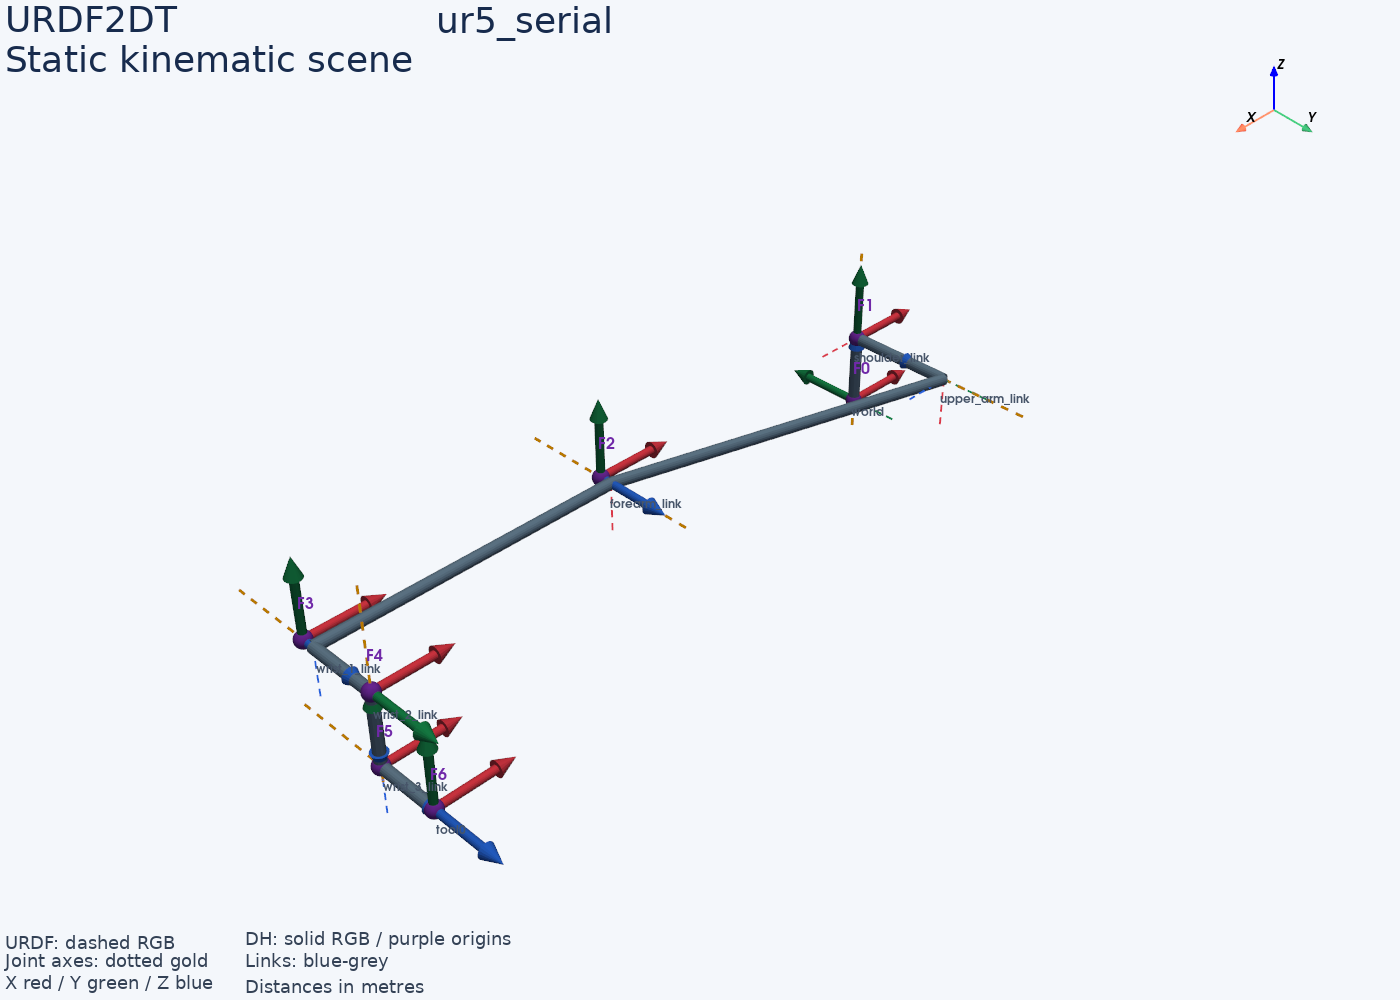

In [7]:
scene_path = output_dir / 'automatic_scene.png'
StaticScene(chain, automatic).render(scene_path)
assert scene_path.stat().st_size > 0
display(Image(filename=str(scene_path), width=900))

## 8. Geometric classification
Each row compares consecutive DH z axes. Legal controls depend on the measured geometry; the terminal pair follows the solver convention and is not another physical joint.

In [8]:
cases = classify_dh_model(automatic, config.geometry)
for i, case in enumerate(cases, 1):
    controls = [p.name + ' [' + p.unit + ']' for p in get_editable_params(case)]
    print(f'F{i}: {case.case.value}; controls={controls}; review={case.requires_review}')
    print(' ', case.description)

F1: intersecting; controls=[]; review=False
  Intersecting axes: the intersection fixes the origin; no continuous frame freedom.
F2: parallel; controls=['axial_translation [m]']; review=False
  Parallel axes: the common normal can slide along the axes.
F3: parallel; controls=['axial_translation [m]']; review=False
  Parallel axes: the common normal can slide along the axes.
F4: intersecting; controls=[]; review=False
  Intersecting axes: the intersection fixes the origin; no continuous frame freedom.
F5: intersecting; controls=[]; review=False
  Intersecting axes: the intersection fixes the origin; no continuous frame freedom.
F6: parallel; controls=['axial_translation [m]', 'axial_rotation [rad]']; review=False
  Coincident axes: axial translation and rotation are local frame freedoms.


## 9. Guided editing: preview, reject, accept

Walk through frames in order. At the first frame with legal axial translation, preview a **0.025 m frame shift**, reject it to verify that the committed model stays unchanged, then propose it again and accept. Other frames are confirmed at their current values. This changes DH frame placement with adjacent/tool compensation; it does not command physical joint motion.

The walkthrough chooses the freedom from classification rather than assuming a particular UR5 frame number. Local acceptance still requires the global FK check below.

In [9]:
edited_frame = None
for index in range(1, len(automatic.rows) + 1):
    session.unlock_next()
    case = classify_dh_model(session.state.working_model, config.geometry)[index - 1]
    freedoms = {p.name for p in get_editable_params(case)}
    edit = FrameEdit(axial_translation=0.025) if edited_frame is None and 'axial_translation' in freedoms else FrameEdit()
    before = session.state.working_model
    session.propose_edit(index, edit)
    if edit.axial_translation:
        preview = recompute_model(before, index, edit, config.geometry)
        assert preview != before and session.state.working_model == before
        session.reject('Worked example: reject the first preview.')
        assert session.pending is None and session.state.working_model == before
        session.propose_edit(index, edit)
        edited_frame = index
    decision = session.accept()
    assert decision.valid, decision.reason
    print(f'F{index}: {decision.reason}')
assert edited_frame is not None, 'Fixture must exercise a nonzero geometric edit.'
assert session.state.automatic_model == automatic
assert session.state.working_model != automatic
assert all(state == FrameState.ACCEPTED for state in session.state.frames)
print('Nonzero frame edit:', edited_frame, '; audit events:', len(session.events))

F1: Geometric frame edit validated with adjacent compensation.
F2: Geometric frame edit validated with adjacent compensation.
F3: Geometric frame edit validated with adjacent compensation.
F4: Geometric frame edit validated with adjacent compensation.
F5: Geometric frame edit validated with adjacent compensation.
F6: Geometric frame edit validated with adjacent compensation.
Nonzero frame edit: 2 ; audit events: 20


## 10. Final DH table
Compare these rows with the baseline above. The end-effector should remain equivalent despite different frame origins.

In [10]:
show_model(session.state.working_model)
print('Final base transform:', session.state.working_model.base_transform)
print('Final tool transform:', session.state.working_model.tool_transform)

a,alpha,d,theta_offset,joint_name,joint_type,joint_sign
0,1.5707963,0.089159,0,shoulder_pan_joint,JointType.REVOLUTE,1
-0.425,0,0.025,-4.8965733e-12,shoulder_lift_joint,JointType.REVOLUTE,1
-0.39225,0,-0.025,-1.2591102e-17,elbow_joint,JointType.REVOLUTE,1
0,1.5707963,0.10915,-4.8965918e-12,wrist_1_joint,JointType.REVOLUTE,1
-9.3203376e-19,-1.5707963,0.09465,0,wrist_2_joint,JointType.REVOLUTE,1
0,0,0.0823,0,wrist_3_joint,JointType.REVOLUTE,1


Final base transform: ((-1.0, 0.0, 0.0, 0.0), (0.0, -1.0, 0.0, 0.0), (0.0, 0.0, 1.0, 0.0), (0.0, 0.0, 0.0, 1.0))
Final tool transform: ((1.0, 0.0, 0.0, 3.954443108431834e-17), (0.0, 1.0, -4.8965888601467475e-12, 1.2723702198930902e-19), (0.0, 4.8965888601467475e-12, 1.0, 0.0), (0.0, 0.0, 0.0, 1.0))


## 11. Global FK validation
Compare both automatic and edited DH against URDF FK using the configured deterministic sample set. A failed check stops the notebook before export.

In [11]:
baseline_report = validate_global_fk(chain, automatic, config)
report = validate_global_fk(chain, session.state.working_model, config)
assert baseline_report.passed, baseline_report.markdown()
assert report.passed, report.markdown()
print('Automatic and edited sampled FK: PASS')

Automatic and edited sampled FK: PASS


## 12. Validation metrics
Position error is in metres and orientation error in radians. These results apply only to this source, configuration, model and sampled poses.

In [12]:
display(Markdown(report.markdown()))
print('Automatic summary:', json.dumps(baseline_report.to_dict()['summary'], indent=2))
print('Edited summary:', json.dumps(report.to_dict()['summary'], indent=2))

# Sampled global FK: PASS

Candidate: `24c1b1c1e06b6646096453a60996de0637860c2f5e42509e97553729e56de5ff`

Git commit: 23512a99e0fba1e25ed68cdd332d8534fff80c44; working tree clean: True.

Samples: 50; reference status: provisional.

Tolerances: 0.0001 m / 0.0001 rad.

Position max/mean: 4.44102762e-16 / 1.23526462e-16 m.

Orientation max/mean: 2.98023224e-08 / 6.49660524e-09 rad.

Worst position/orientation sample indices (zero-based): 48 / 25.

All sampled end-effector poses are within configured tolerances.

Sampled evidence only; not a continuous-space proof.


Automatic summary: {
  "max_position_error_m": 4.441027621704298e-16,
  "mean_position_error_m": 1.2276193477342662e-16,
  "max_orientation_error_rad": 2.9802322387695312e-08,
  "mean_orientation_error_rad": 6.496605239279071e-09,
  "worst_position_sample": 48,
  "worst_orientation_sample": 25
}
Edited summary: {
  "max_position_error_m": 4.441027621704298e-16,
  "mean_position_error_m": 1.2352646209507376e-16,
  "max_orientation_error_rad": 2.9802322387695312e-08,
  "mean_orientation_error_rad": 6.496605239279071e-09,
  "worst_position_sample": 48,
  "worst_orientation_sample": 25
}


## 13. Export and reload
Export revalidates the complete session. Reload checks source identity, schema, state and sampled FK. Every run uses a new bundle directory; no previous export is overwritten.

In [13]:
archive = save_session(output_dir / 'session', run, session)
loaded = load_session(archive)
assert loaded.session.state == session.state
expected = {'session.json', 'dh_model.json', 'edit_history.json', 'validation_report.json', 'configuration.json', 'validation_report.md'}
assert expected <= {p.name for p in archive.parent.iterdir()}
for path in sorted(archive.parent.iterdir()):
    print(path.relative_to(ROOT), ':', path.stat().st_size, 'bytes')
print('Reloaded state matches. Archive:', archive)
summary = {'source_sha256': source.sha256, 'edited_frame': edited_frame,
           'baseline_passed': baseline_report.passed, 'edited_passed': report.passed,
           'round_trip_equal': loaded.session.state == session.state,
           'metrics': report.to_dict()['summary'], 'archive': str(archive)}
(output_dir / 'verification.json').write_text(json.dumps(summary, indent=2) + '\n', encoding='utf-8')

outputs\notebooks\ur5_worked_70nom0s_\session\configuration.json : 489 bytes
outputs\notebooks\ur5_worked_70nom0s_\session\dh_model.json : 2906 bytes
outputs\notebooks\ur5_worked_70nom0s_\session\edit_history.json : 79883 bytes
outputs\notebooks\ur5_worked_70nom0s_\session\session.json : 161653 bytes
outputs\notebooks\ur5_worked_70nom0s_\session\validation_report.json : 66163 bytes
outputs\notebooks\ur5_worked_70nom0s_\session\validation_report.md : 703 bytes
Reloaded state matches. Archive: C:\Users\abdel\OneDrive\Desktop\URDF2DT\outputs\tmp\stage21-checkout\outputs\notebooks\ur5_worked_70nom0s_\session\session.json


654

## Optional: try the live guided editor

Set `OPEN_LIVE_EDITOR = True` and run the next cell to open an independent interactive session. Select a frame, change a legal value, choose **Preview**, then **Accept** or **Reject preview**. Use **Unlock next** and repeat; accept every frame before **Validate FK** and **Save session**. The separate session keeps the reproducible worked result above intact.

For instantaneous physical joint motion in a native application, run:
```powershell
.\.venv\Scripts\python.exe -m urdf2dt.ui.desktop robots/ur5/ur5_serial.urdf
```
Notebook widgets require a running Python kernel; GitHub's notebook preview is static.

In [14]:
OPEN_LIVE_EDITOR = False
if OPEN_LIVE_EDITOR:
    from urdf2dt.ui.dh_editor import DHEditor
    editor = DHEditor()
    editor.load(str(source_path))
    editor.archive_path.value = str(output_dir / 'interactive_session')
    editor.display()
else:
    print('Worked example complete. Enable OPEN_LIVE_EDITOR to experiment interactively.')

Worked example complete. Enable OPEN_LIVE_EDITOR to experiment interactively.
